## Model D: Custom

In [138]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report
import kagglehub
import os
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [139]:
# Download latest version
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plant-disease-recognition-dataset' dataset.
Path to dataset files: /kaggle/input/plant-disease-recognition-dataset


In [140]:
# Walk through the dataset directory and print its structure
for root, dirs, files in os.walk(path):
    # Calculate the folder depth for indentation
    level = root.replace(path, "").count(os.sep)
    indent = " " * 2 * level

    print(f"{indent}{os.path.basename(root)}/")

    # Show only the first 3 files in each folder (avoid long output)
    sub_indent = " " * 2 * (level + 1)
    for file in files[:3]:
        print(f"{sub_indent}{file}")

    if len(files) > 3:
        print(f"{sub_indent}... and {len(files) - 3} more files")

plant-disease-recognition-dataset/
  Validation/
    Validation/
      Healthy/
        9d0f6e60819f9a5a.jpg
        9ccf708985967f09.jpg
        9ccbc2c5d1aaf078.jpg
        ... and 17 more files
      Rust/
        8219aa662e8fd59d.jpg
        929b16251fcaafc4.jpg
        851edcf908ed2e1c.jpg
        ... and 17 more files
      Powdery/
        9ab326c1951acb7a.jpg
        9bd06de433b285d8.jpg
        9ad5df40909ae24f.jpg
        ... and 17 more files
  Test/
    Test/
      Healthy/
        8e8470687be37378.jpg
        8def3f60308ab41b.jpg
        8ddaac1bd6c8cd0a.jpg
        ... and 47 more files
      Rust/
        93e896990cb365b5.jpg
        85f0c2c0db4b4f4f.jpg
        89bc19fcf830c6e8.jpg
        ... and 47 more files
      Powdery/
        86b3343b83d1b86e.jpg
        83d867d86f14c62b.jpg
        85b12ed31e7d6852.jpg
        ... and 47 more files
  Train/
    Train/
      Healthy/
        93a7c1dd2fe04f20.jpg
        94a386b68ebfd0d0.jpg
        82fc37c398513727.jpg
        .

In [141]:
# Define the exact paths based on the nested folder structure we discovered
train_dir = os.path.join(path, "Train", "Train")
test_dir = os.path.join(path, "Test", "Test")
valid_dir = os.path.join(path, "Validation", "Validation")

class_names = ["Healthy", "Powdery", "Rust"]

# Function to count images in each class folder
def count_images(base_dir, class_names):
    counts = {}
    for class_name in class_names:
        class_path = os.path.join(base_dir, class_name)
        num_files = len(os.listdir(class_path))
        counts[class_name] = num_files
    return counts

print("Train counts:", count_images(train_dir, class_names))
print("Test counts:", count_images(test_dir, class_names))
print("Validation counts:", count_images(valid_dir, class_names))

Train counts: {'Healthy': 458, 'Powdery': 430, 'Rust': 434}
Test counts: {'Healthy': 50, 'Powdery': 50, 'Rust': 50}
Validation counts: {'Healthy': 20, 'Powdery': 20, 'Rust': 20}


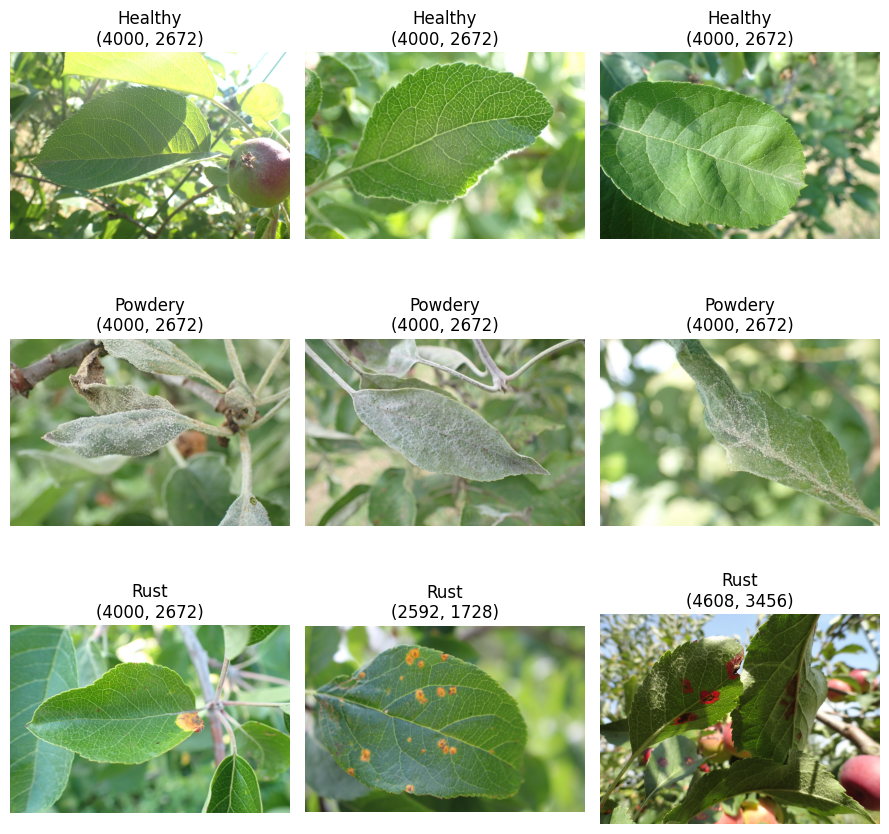

In [142]:
import matplotlib.pyplot as plt
from PIL import Image

# Create a grid: 3 rows (one per class), 3 columns (sample images)
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for row, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    # Get the first 3 image filenames in this class folder
    sample_files = os.listdir(class_path)[:3]

    for col, file_name in enumerate(sample_files):
        img_path = os.path.join(class_path, file_name)
        img = Image.open(img_path)

        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(f"{class_name}\n{img.size}")
        ax.axis("off")

plt.tight_layout()
plt.show()

### Input Resizing

In [143]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 42

# Load the training dataset directly from folders
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

# Load the validation dataset
valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

# Load the test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

Found 1322 files belonging to 3 classes.
Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.


In [144]:
# NOTE: Speeding up the data pipeline before training
# - cache()    -> keeps images in memory after first read (faster next epoch)
# - shuffle()  -> randomizes order (train set only)
# - prefetch() -> prepares next batch while current one is training

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)   # no shuffle: keep order fixed for evaluation
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)     # no shuffle: keep order fixed for evaluation

In [145]:
from tensorflow.keras import layers, Model

def build_model_c(num_classes: int) -> Model:
    inputs = keras.Input(shape=(160, 160, 3))

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(32, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)   # Changed from default 0.99
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)   # Changed from default 0.99
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)   # Changed from default 0.99
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="Model_D_Custom")

In [146]:
def build_cnn(num_classes: int, config: dict) -> keras.Model:
    inputs = keras.Input(shape=(160, 160, 3))
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.RandomFlip("horizontal")(x)

    for filters in config["filters"]:
        x = layers.Conv2D(filters, kernel_size=config["kernel_size"], padding="same", use_bias=not config["batch_norm"])(x)
        if config["batch_norm"]:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)


    x = layers.Dropout(config["dropout"])(x)

    # ======== NEW ADDED ==== ======================
    for dense in config["dense"]:
        x = layers.Dense(dense, activation="relu")(x)
    # ======== ============== ======================

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name=config["name"])

In [162]:
config = {
    "name": "Model_A_Baseline",
    "filters": [32, 64],
    "kernel_size": (3, 3),
    "batch_norm": False,
    "dropout": 0.3,
    "dense": [32]
}

optimizer_a = keras.optimizers.Adam(learning_rate=0.05)
model_a = build_cnn(3, config)
model_a.compile(
    optimizer= optimizer_a,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [150]:
optimizer = keras.optimizers.Adam(learning_rate=0.05)
model_d = build_model_c(num_classes=len(class_names))
model_d.summary()
model_d.compile(
    optimizer= optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


Model: "Model_D_Custom"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_32 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_32 (RandomFlip)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_22              │ (None, 160, 160, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_22 (RandomZoom)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_32 (Rescaling)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 160, 160, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_84 (Activation)      │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_84 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 80, 80, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_85 (Activation)      │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_85 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 40, 40, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_86 (Activation)      │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_86 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_31     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,307 (368.39 KB)

 Trainable params: 93,859 (366.64 KB)

 Non-trainable params: 448 (1.75 KB)

In [165]:

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="model_c_best.keras",
    monitor="val_loss",
    save_best_only=True
)

history_d = model_d.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9183 - loss: 0.2418 - val_accuracy: 0.6333 - val_loss: 1.3676
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9244 - loss: 0.2306 - val_accuracy: 0.7333 - val_loss: 1.1549
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9175 - loss: 0.2393 - val_accuracy: 0.8000 - val_loss: 0.7052
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9115 - loss: 0.2770 - val_accuracy: 0.4667 - val_loss: 6.3023
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9228 - loss: 0.2303 - val_accuracy: 0.8000 - val_loss: 1.0647
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9289 - loss: 0.1956 - val_accuracy: 0.7500 - val_loss: 1.0228
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9387 - loss: 0.1970 - val_accuracy: 0.8167 - val_loss: 0.8336
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9130 - loss: 0.2582 - val_accuracy: 0.9167 - v

In [164]:
history_a = model_a.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 58s 115ms/step - accuracy: 0.3079 - loss: 1.2323 - val_accuracy: 0.3333 - val_loss: 1.0996
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3313 - loss: 1.1010 - val_accuracy: 0.3333 - val_loss: 1.0998
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3290 - loss: 1.1025 - val_accuracy: 0.3333 - val_loss: 1.1010
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3230 - loss: 1.1016 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3275 - loss: 1.1010 - val_accuracy: 0.3333 - val_loss: 1.1006


In [166]:
import numpy as np

# Find the epoch with the lowest validation loss
val_loss_values = history_d.history["val_loss"]
best_epoch = np.argmin(val_loss_values)

print(f"Best epoch: {best_epoch + 1}")
print(f"Best val_loss: {val_loss_values[best_epoch]:.4f}")
print(f"Best val_accuracy: {history_d.history['val_accuracy'][best_epoch]:.4f}")

Best epoch: 9
Best val_loss: 0.2344
Best val_accuracy: 0.9500


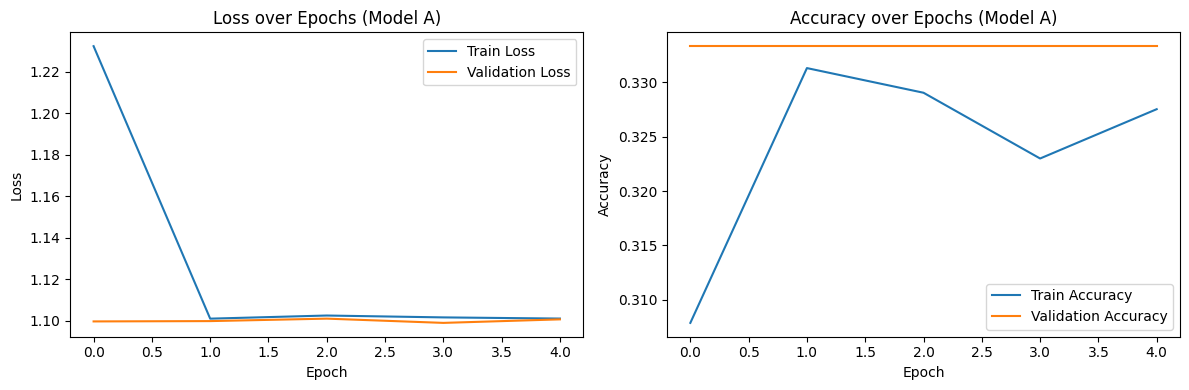

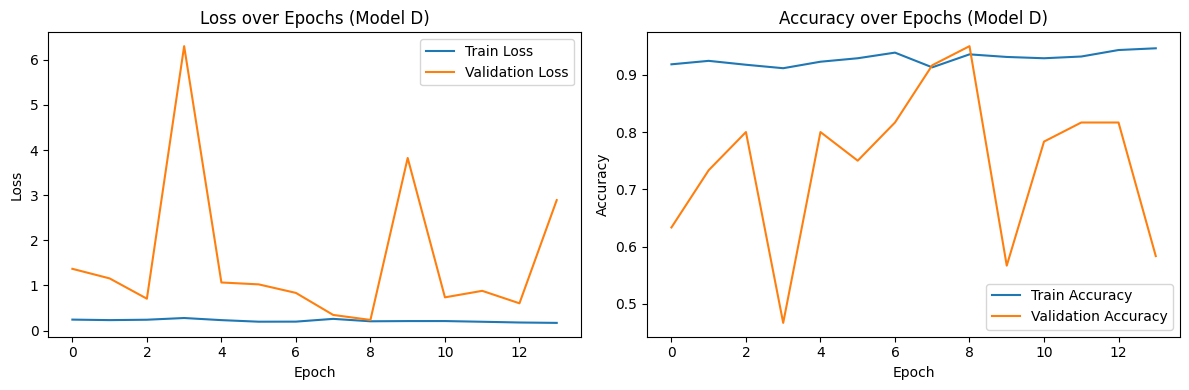

In [170]:
import matplotlib.pyplot as plt

def plot_performance(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot 1: Loss curves
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(f"Loss over Epochs ({name})")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Plot 2: Accuracy curves
    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[1].set_title(f"Accuracy over Epochs ({name})")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_performance(history_a, "Model A")
plot_performance(history_d, "Model D")

# Testing

In [171]:
def test_and_report(history):
    y_pred_probs = history.model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)

    y_test = np.concatenate([y for x, y in test_ds], axis=0)

    # convert them to class indices first:
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_test = np.argmax(y_test, axis=1)

    report = classification_report(y_test, y_pred)
    print(report)


In [174]:
test_and_report(history_a)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step
              precision    recall  f1-score   support

           0       0.33      1.00      0.50        50
           1       0.00      0.00      0.00        50
           2       0.00      0.00      0.00        50

    accuracy                           0.33       150
   macro avg       0.11      0.33      0.17       150
weighted avg       0.11      0.33      0.17       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [175]:
test_and_report(history_d)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
              precision    recall  f1-score   support

           0       0.80      0.98      0.88        50
           1       1.00      0.80      0.89        50
           2       0.98      0.96      0.97        50

    accuracy                           0.91       150
   macro avg       0.93      0.91      0.91       150
weighted avg       0.93      0.91      0.91       150

